# Chapter 16 Lab — Artifacts and Noise in fMRI (Python)

Real fMRI noise is not a featureless hiss: it drifts, it repeats itself, it spikes, and it carries the imprint of the beating heart. In this lab you will build an fMRI-like time series from its noise ingredients, then learn to diagnose each one:

1. **Simulate a noisy voxel** from known components: slow drift, AR(1) autocorrelated noise, transient spikes, and a heartbeat sampled at the TR
2. **Move to the frequency domain** to see 1/f drift and demonstrate temporal aliasing — including why a 1 Hz heartbeat shows up as low-frequency noise
3. **Detect transient outliers** in a multi-voxel dataset with RMSSD/DVARS and Mahalanobis distance, and build spike regressors
4. **Measure what autocorrelation does to naive OLS** — and fix it with prewhitening

Because we build the noise ourselves, we know the ground truth, so every diagnostic can be checked against what we put in.

**How to run this notebook.** Run it in your browser from the tutorial site, in Google Colab, or in a local Jupyter installation. It uses only `numpy`, `scipy`, `pandas`, and `matplotlib`, and all data are simulated — nothing to download. It accompanies the [chapter page](../ch16-artifacts-and-noise-in-fmri.md).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, signal

rng = np.random.default_rng(7)
np.set_printoptions(precision=3, suppress=True)
print("numpy", np.__version__)

numpy 2.4.6


## Part 1 — Anatomy of a noisy voxel time series

We simulate an 8-minute run (240 volumes, TR = 2 s) and add up four noise ingredients on top of a constant baseline of 100:

- **Slow drift** — a sum of slow cosines, mimicking scanner instability and slow physiological change. In real data, drift power grows in inverse proportion to frequency ("1/f noise").
- **AR(1) autocorrelated noise** — noise that "remembers" its recent past:

$$\epsilon_t = \phi\, \epsilon_{t-1} + \eta_t, \qquad \eta_t \sim N(0, \sigma^2)$$

  with $\phi = 0.5$. Each time point inherits half of the previous deviation, so errors are correlated across time.
- **A heartbeat** — simulated at high temporal resolution (50 Hz) as a train of pulses at ~60 beats/min with natural beat-to-beat jitter, then *sampled once per TR*, exactly as the scanner does.
- **Transient spikes** — three volumes with sudden intensity shifts, standing in for gradient glitches or abrupt head movement.

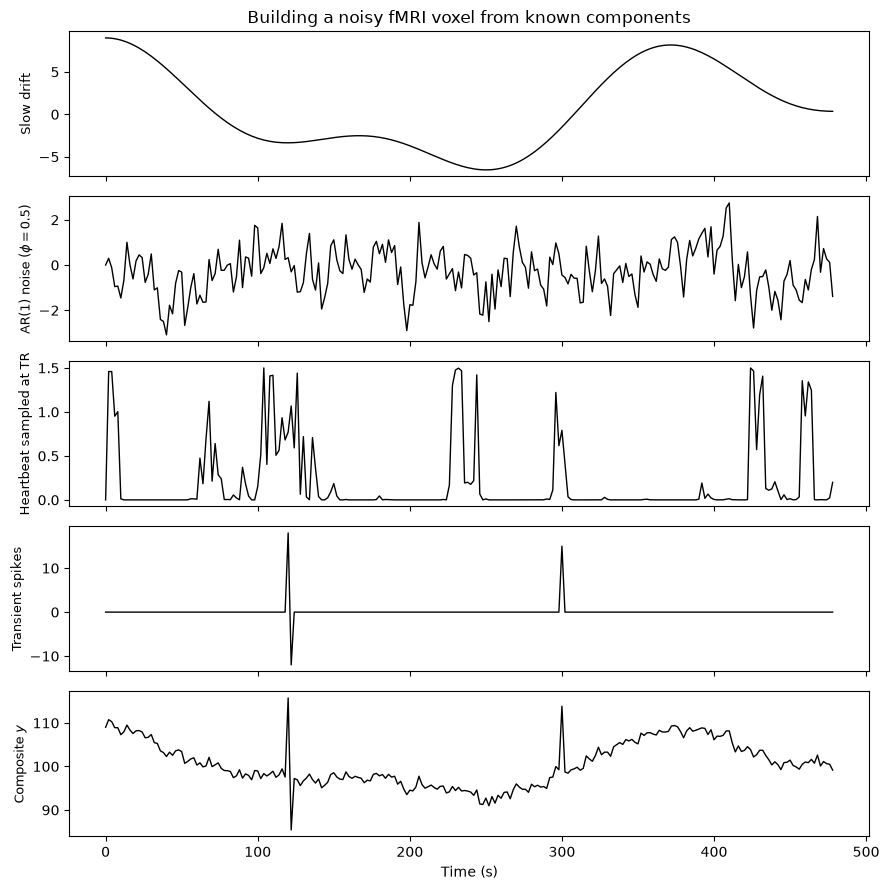

In [2]:
TR, n = 2.0, 240
t = np.arange(n) * TR                     # volume acquisition times (s)

# --- Slow drift: sum of slow cosines -------------------------------------
drift = 6 * np.cos(2 * np.pi * t / 400) + 3 * np.cos(2 * np.pi * t / 180)

# --- AR(1) noise, phi = 0.5 ----------------------------------------------
phi = 0.5
eta = rng.standard_normal(n)
ar1 = signal.lfilter([1.0], [1.0, -phi], eta)   # e_t = phi*e_{t-1} + eta_t

# --- Heartbeat at ~60 bpm, built at 50 Hz then sampled at the TR ---------
dt = 0.02                                 # high-resolution time step (s)
t_hi = np.arange(0, n * TR, dt)
beats = np.cumsum(rng.normal(1.0, 0.05, size=int(n * TR * 1.3)))  # jittered
beats = beats[beats < t_hi[-1]]
hb_hi = np.zeros_like(t_hi)
for b in beats:                           # each beat: a narrow pulse
    hb_hi += np.exp(-0.5 * ((t_hi - b) / 0.06) ** 2)
hb_tr = hb_hi[(t / dt).astype(int)]       # what the scanner sees: 1 sample/TR

# --- Transient spikes ----------------------------------------------------
spikes = np.zeros(n)
spike_vols = np.array([60, 61, 150])
spikes[spike_vols] = [18, -12, 15]

# --- Composite voxel time series -----------------------------------------
y = 100 + drift + ar1 + 1.5 * hb_tr + spikes

fig, axes = plt.subplots(5, 1, figsize=(9, 9), sharex=True)
for ax, sig_, name in zip(
        axes,
        [drift, ar1, 1.5 * hb_tr, spikes, y],
        ["Slow drift", "AR(1) noise ($\phi=0.5$)",
         "Heartbeat sampled at TR", "Transient spikes", "Composite $y$"]):
    ax.plot(t, sig_, lw=1, color="k")
    ax.set_ylabel(name, fontsize=9)
axes[-1].set_xlabel("Time (s)")
axes[0].set_title("Building a noisy fMRI voxel from known components")
plt.tight_layout()

Look at the heartbeat panel: the underlying signal beats once per second, but sampled every 2 s it looks like a slow, irregular wander — nothing like a 1 Hz oscillation. That is **temporal aliasing**, and Part 2 shows exactly why it happens.

## Part 2 — Time and frequency domains, and the aliasing trap

The Fourier transform re-expresses a time series, without loss of information, as a sum of sine waves, each with a magnitude and phase; plotting power against frequency gives the **power spectral density (PSD)**. Sampling imposes a hard limit: by the **Nyquist theorem**, a sampling rate $F_s$ can only represent frequencies up to

$$f_{\mathrm{Nyquist}} = \frac{F_s}{2} = \frac{1}{2\,\mathrm{TR}}.$$

Frequencies above the limit are *reflected* around it and reappear below — they alias. First, the classic demonstration: a 10 Hz sine wave sampled at only 12 Hz (Nyquist limit 6 Hz) masquerades as a 2 Hz oscillation.

Aliased frequency predicted by reflection: 2 Hz


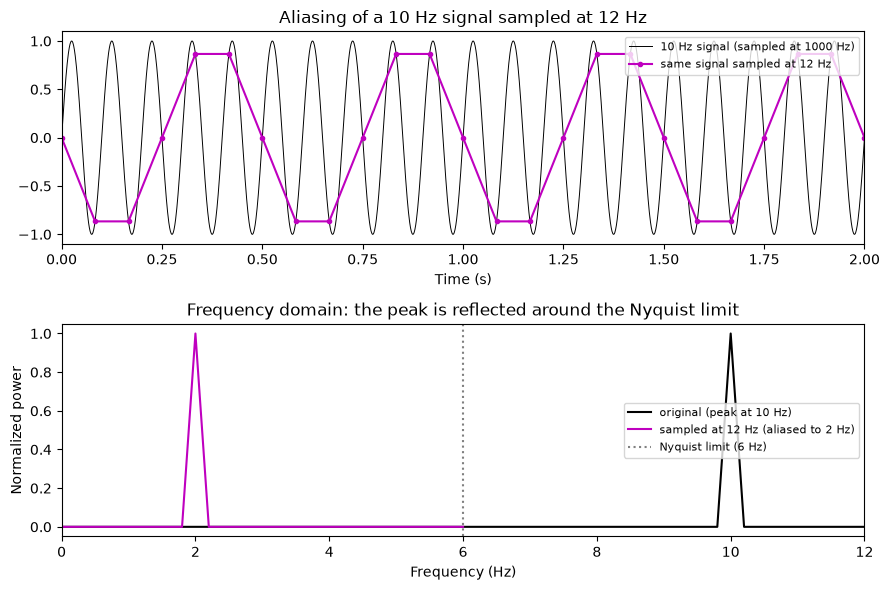

In [3]:
fs_hi, fs_lo, dur, f_sig = 1000, 12, 5, 10          # Hz, Hz, s, Hz
tt_hi = np.arange(0, dur, 1 / fs_hi)
tt_lo = np.arange(0, dur, 1 / fs_lo)
x_hi = np.sin(2 * np.pi * f_sig * tt_hi)
x_lo = np.sin(2 * np.pi * f_sig * tt_lo)

f1, p1 = signal.periodogram(x_hi, fs=fs_hi)
f2, p2 = signal.periodogram(x_lo, fs=fs_lo)

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(9, 6))
ax0.plot(tt_hi, x_hi, "k", lw=0.7, label="10 Hz signal (sampled at 1000 Hz)")
ax0.plot(tt_lo, x_lo, "m.-", lw=1.5, label="same signal sampled at 12 Hz")
ax0.set(xlabel="Time (s)", xlim=(0, 2),
        title="Aliasing of a 10 Hz signal sampled at 12 Hz")
ax0.legend(loc="upper right", fontsize=8)

ax1.plot(f1, p1 / p1.max(), "k", label="original (peak at 10 Hz)")
ax1.plot(f2, p2 / p2.max(), "m", label="sampled at 12 Hz (aliased to 2 Hz)")
ax1.axvline(fs_lo / 2, color="gray", ls=":", label="Nyquist limit (6 Hz)")
ax1.set(xlabel="Frequency (Hz)", ylabel="Normalized power", xlim=(0, 12),
        title="Frequency domain: the peak is reflected around the Nyquist limit")
ax1.legend(fontsize=8)
plt.tight_layout()

print(f"Aliased frequency predicted by reflection: {fs_lo - f_sig} Hz")

The 10 Hz peak is reflected around the 6 Hz Nyquist limit and lands at 12 − 10 = 2 Hz. Now the version that matters for fMRI: our ~1 Hz heartbeat sampled at TR = 2 s, where the Nyquist limit is 1/(2 × 2) = **0.25 Hz**.

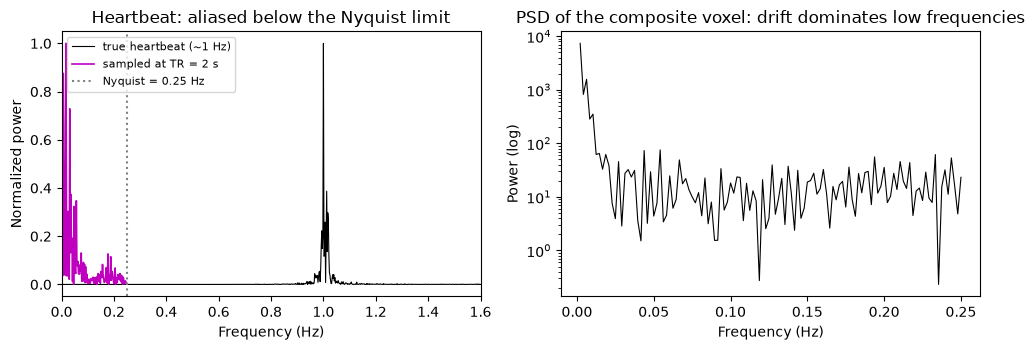

In [4]:
f_hb, p_hb = signal.periodogram(hb_hi - hb_hi.mean(), fs=1 / dt)
f_tr, p_tr = signal.periodogram(hb_tr - hb_tr.mean(), fs=1 / TR)
f_y, p_y = signal.periodogram(y - y.mean(), fs=1 / TR)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 3.6))
ax0.plot(f_hb, p_hb / p_hb.max(), "k", lw=0.8, label="true heartbeat (~1 Hz)")
ax0.plot(f_tr, p_tr / p_tr.max(), "m", lw=1.2, label="sampled at TR = 2 s")
ax0.axvline(1 / (2 * TR), color="gray", ls=":", label="Nyquist = 0.25 Hz")
ax0.set(xlabel="Frequency (Hz)", ylabel="Normalized power", xlim=(0, 1.6),
        title="Heartbeat: aliased below the Nyquist limit")
ax0.legend(fontsize=8)

ax1.semilogy(f_y[1:], p_y[1:], "k", lw=0.8)
ax1.set(xlabel="Frequency (Hz)", ylabel="Power (log)",
        title="PSD of the composite voxel: drift dominates low frequencies")
plt.tight_layout()

The heartbeat's power, truly at ~1 Hz, reappears entirely below 0.25 Hz — in the same band as the task and the drift. Because the aliased pattern shifts dramatically with small beat-to-beat timing changes, it cannot be cleanly filtered out or modeled with simple covariates; this is why fast (multiband) sampling or physiological recordings are so valuable.

## Part 3 — Detecting transient outliers: RMSSD/DVARS and Mahalanobis distance

Real QC works on whole image volumes, not single voxels. We simulate a small "brain" of 200 voxels sharing drift and heartbeat components (with voxel-specific weights) plus voxel-specific AR(1) noise, and corrupt the same three volumes with spatially widespread intensity shifts.

Two standard diagnostics, both used in CANlab's `scnlab_outlier_id` and `fmri_data.mahal` QC tools:

- **RMSSD (DVARS)** — the root-mean-square change from each image to the next:

$$\mathrm{RMSSD}_t = \sqrt{\tfrac{1}{V} \sum_{v=1}^{V} (y_{v,t} - y_{v,t-1})^2}$$

  BOLD changes slowly, so a big image-to-image jump flags a transient artifact.
- **Mahalanobis distance** — how far each image lies from the multivariate cloud of all images (computed here on the first 5 principal components), flagging globally unusual volumes.

True corrupted volumes: [ 60  61 150]
Flagged by RMSSD > 3 SD: [ 60  61  62 150 151]


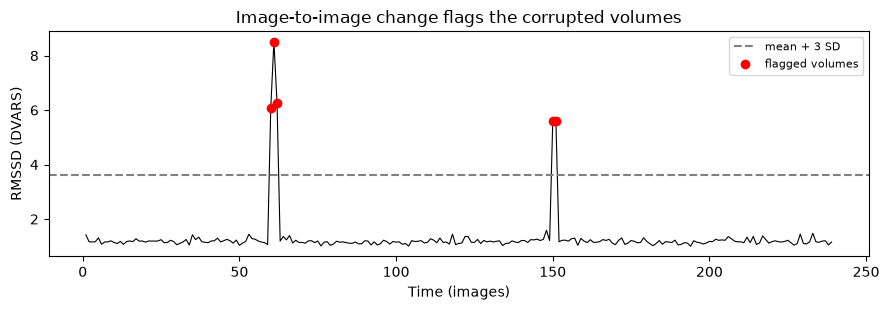

In [5]:
V = 200                                        # number of voxels
w_drift = rng.uniform(0.2, 1.5, size=V)        # voxel-specific loadings
w_hb = rng.uniform(0.0, 1.0, size=V)
eta_mat = rng.standard_normal((n, V))
noise = signal.lfilter([1.0], [1.0, -phi], eta_mat, axis=0)

Y = (100 + np.outer(drift, w_drift) + np.outer(1.5 * hb_tr, w_hb) + noise)
Y[spike_vols] += rng.normal(0, 6, size=(len(spike_vols), V))   # corrupt 3 vols

# --- RMSSD / DVARS -------------------------------------------------------
rmssd = np.sqrt(np.mean(np.diff(Y, axis=0) ** 2, axis=1))      # length n-1
z_rmssd = (rmssd - rmssd.mean()) / rmssd.std()
flag_rmssd = np.where(z_rmssd > 3)[0] + 1      # +1: diff t-1 -> t flags t

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(np.arange(1, n), rmssd, "k", lw=0.8)
thresh = rmssd.mean() + 3 * rmssd.std()
ax.axhline(thresh, color="gray", ls="--", label="mean + 3 SD")
ax.plot(flag_rmssd, rmssd[flag_rmssd - 1], "ro", label="flagged volumes")
ax.set(xlabel="Time (images)", ylabel="RMSSD (DVARS)",
       title="Image-to-image change flags the corrupted volumes")
ax.legend(fontsize=8)
plt.tight_layout()

print("True corrupted volumes:", spike_vols)
print("Flagged by RMSSD > 3 SD:", flag_rmssd)

One caution visible in the code: a spike at volume $t$ produces large successive differences both *into* and *out of* the artifact, so RMSSD may flag the volume after a spike as well. In practice, adjacent flagged volumes are usually all treated as outliers.

Now the multivariate view. We reduce the 200-voxel images to their first 5 principal components and compute each volume's Mahalanobis distance from the cloud; under approximate normality, squared distances follow a $\chi^2_5$ distribution, giving a principled threshold.

Flagged by Mahalanobis: [ 60  61 150]


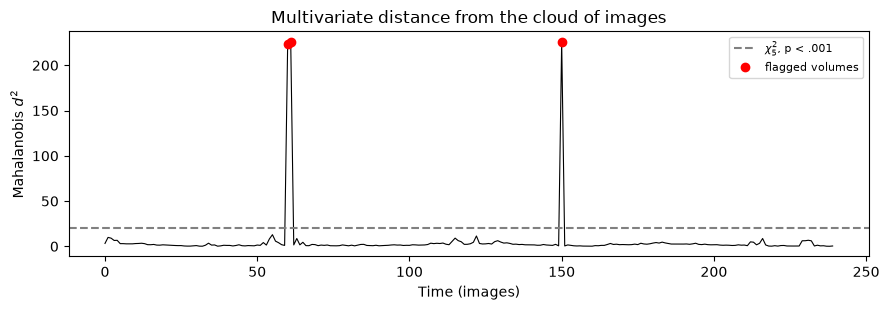

In [6]:
Yc = Y - Y.mean(axis=0)
U, s, Vt = np.linalg.svd(Yc, full_matrices=False)
k = 5
scores = U[:, :k] * s[:k]                      # n x k PC scores per volume

Sinv = np.linalg.inv(np.cov(scores, rowvar=False))
d = scores - scores.mean(axis=0)
md2 = np.einsum("ij,jk,ik->i", d, Sinv, d)     # squared Mahalanobis distance

chi2_thresh = stats.chi2.ppf(0.999, df=k)      # expect ~0.1% false flags
flag_mahal = np.where(md2 > chi2_thresh)[0]

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(md2, "k", lw=0.8)
ax.axhline(chi2_thresh, color="gray", ls="--", label="$\chi^2_5$, p < .001")
ax.plot(flag_mahal, md2[flag_mahal], "ro", label="flagged volumes")
ax.set(xlabel="Time (images)", ylabel="Mahalanobis $d^2$",
       title="Multivariate distance from the cloud of images")
ax.legend(fontsize=8)
plt.tight_layout()

print("Flagged by Mahalanobis:", flag_mahal)

Finally, we handle the outliers the recommended way — not by deleting time points, but by adding one **spike regressor** per flagged volume to the design matrix. Each regressor is 1 at its bad volume and 0 elsewhere, which removes that image's influence on the fit while preserving the timing and noise structure of the series. (Deleting time points changes the noise properties, forces re-timing of the design, and can bias sampling when outliers are task-correlated.)

In [7]:
flagged = np.unique(np.concatenate([flag_rmssd, flag_mahal]))
spike_regs = np.zeros((n, len(flagged)))
spike_regs[flagged, np.arange(len(flagged))] = 1.0

print(pd.DataFrame({
    "volume": flagged,
    "true outlier": np.isin(flagged, spike_vols),
    "RMSSD flag": np.isin(flagged, flag_rmssd),
    "Mahalanobis flag": np.isin(flagged, flag_mahal),
}).to_string(index=False))
print("\nSpike regressor matrix shape:", spike_regs.shape,
      "-> add these columns to the design matrix X")

 volume  true outlier  RMSSD flag  Mahalanobis flag
     60          True        True              True
     61          True        True              True
     62         False        True             False
    150          True        True              True
    151         False        True             False

Spike regressor matrix shape: (240, 5) -> add these columns to the design matrix X


## Part 4 — Autocorrelation and its consequences for naive OLS

Even after drift removal and outlier handling, fMRI noise remains autocorrelated. For AR(1) noise, the theoretical autocorrelation function (ACF) decays geometrically: $\mathrm{corr}(\epsilon_t, \epsilon_{t-k}) = \phi^{k}$. Let's check the empirical ACF of our noise against theory.

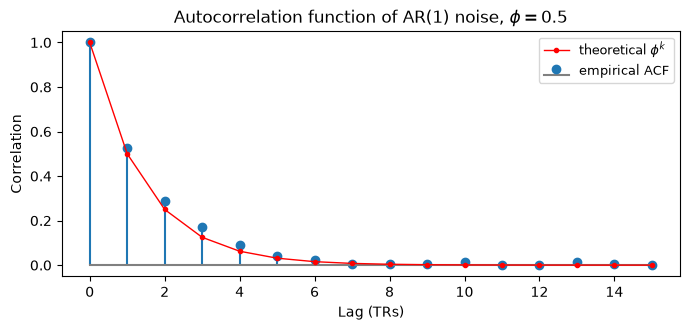

In [8]:
e = signal.lfilter([1.0], [1.0, -phi], rng.standard_normal(5000))
max_lag = 15
acf = np.array([1.0] + [np.corrcoef(e[:-k], e[k:])[0, 1]
                        for k in range(1, max_lag + 1)])

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.stem(np.arange(max_lag + 1), acf, basefmt="gray", label="empirical ACF")
ax.plot(np.arange(max_lag + 1), phi ** np.arange(max_lag + 1), "r.-",
        lw=1, label=r"theoretical $\phi^k$")
ax.set(xlabel="Lag (TRs)", ylabel="Correlation",
       title="Autocorrelation function of AR(1) noise, $\phi = 0.5$")
ax.legend(fontsize=9)
plt.tight_layout()

Why does this matter? OLS standard errors assume independent errors. Positively autocorrelated noise contains *fewer effectively independent observations* than time points, so OLS underestimates the variability of $\hat\beta$ — and t-statistics are inflated.

To see it, we run a **null simulation**: fit a blocked task regressor (40 s on/off) to pure AR(1) noise containing *no signal whatsoever*, 2,000 times, and count how often naive OLS declares p < .05. If inference were valid, the answer would be ~5%. Then we repeat after **prewhitening** — transforming both $y$ and $X$ so the errors become independent (here using the known $\phi$; real software estimates it from residuals, per Chapter 19).

In [9]:
nsim = 2000
Xd = np.c_[(np.sin(2 * np.pi * t / 80) > 0).astype(float), np.ones(n)]
p_ = Xd.shape[1]
tcrit = stats.t.ppf(0.975, n - p_)

# Generate all null datasets at once: pure AR(1) noise, no signal
E = signal.lfilter([1.0], [1.0, -phi],
                   rng.standard_normal((n, nsim)), axis=0)

def ols_fpr(X, E):
    B = np.linalg.lstsq(X, E, rcond=None)[0]        # p x nsim
    R = E - X @ B
    s2 = np.sum(R ** 2, axis=0) / (n - X.shape[1])
    c00 = np.linalg.inv(X.T @ X)[0, 0]
    tvals = B[0] / np.sqrt(s2 * c00)
    return np.mean(np.abs(tvals) > tcrit)

fpr_naive = ols_fpr(Xd, E)

# Prewhitening: W removes AR(1) dependence (exact transform for known phi)
W = np.eye(n) - phi * np.eye(n, k=-1)
W[0, 0] = np.sqrt(1 - phi ** 2)
fpr_white = ols_fpr(W @ Xd, W @ E)

print(f"False positive rate, naive OLS on AR(1) noise: {fpr_naive:.3f}")
print(f"False positive rate after prewhitening:        {fpr_white:.3f}")
print(f"Nominal rate: 0.050")

False positive rate, naive OLS on AR(1) noise: 0.221
False positive rate after prewhitening:        0.051
Nominal rate: 0.050


Naive OLS produces several times too many false positives — every one of them a "significant activation" in data containing no signal at all. Prewhitening restores the nominal 5% rate. This is exactly why fMRI software estimates the noise autocorrelation and applies generalized least squares (prewhitening) at the first level, as developed in Chapters 18–19.

## Wrap-up

- fMRI noise is structured: slow **drift** (1/f), **autocorrelated** AR-like noise, **transient spikes**, and **physiological** components that alias when sampled at the TR.
- The **Nyquist limit** $1/(2\,\mathrm{TR})$ determines which physiological frequencies survive sampling intact; a 1 Hz heartbeat sampled at TR = 2 s becomes unpredictable low-frequency noise.
- **RMSSD/DVARS** and **Mahalanobis distance** are complementary outlier detectors; flagged volumes are best handled with **spike regressors**, not deletion.
- **Autocorrelation inflates naive OLS t-statistics**; prewhitening (GLS) restores valid inference.

The MATLAB version of this lab mirrors these steps with CANlab tools (`noise_arp`, `scnlab_outlier_id`, `fmri_data.mahal`).